In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from src.data_loader import load_processed
from src.models import create_sequences, build_lstm, recursive_forecast
from src.evaluate import evaluate_forecast

In [2]:
tsla = load_processed("TSLA")

train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Adj Close"]])
test_scaled = scaler.transform(test[["Adj Close"]])

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

print(X_train.shape)

(2456, 60, 1)


In [3]:
model_lstm = build_lstm(window_size)

history = model_lstm.fit(
    X_train, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1, verbose=1
)

c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0088 - val_loss: 0.0028
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 8.6890e-04 - val_loss: 0.0022
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 9.4690e-04 - val_loss: 0.0016
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - 

In [4]:
combined = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined, window_size)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

predictions_scaled = model_lstm.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

metrics = evaluate_forecast(actual.flatten(), predictions.flatten())
print(metrics)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
{'mae': 16.39091196367818, 'rmse': np.float64(20.473473513048816), 'mape': np.float64(4.422698167726971)}


In [5]:
full_scaled = scaler.transform(tsla[["Adj Close"]])
last_60_days = full_scaled[-window_size:]

n_future = 252
future_forecast = recursive_forecast(model_lstm, last_60_days, n_future, scaler, window_size)

future_dates = pd.bdate_range(start=tsla.index[-1] + pd.Timedelta(days=1), periods=n_future)

print(future_forecast[:5].flatten())
print(future_forecast[-5:].flatten())

[372.70984 371.83203 369.21024 365.75217 361.90347]
[231.45464 231.44284 231.43121 231.41983 231.40869]


In [6]:
residual_std = np.std(actual.flatten() - predictions.flatten())

# Widen uncertainty over the horizon — sqrt(t) scaling mirrors how
# forecast uncertainty compounds over time (same principle as annualizing volatility)
horizon = np.arange(1, n_future + 1)
expanding_std = residual_std * np.sqrt(horizon)

upper_bound = future_forecast.flatten() + 1.96 * expanding_std
lower_bound = future_forecast.flatten() - 1.96 * expanding_std

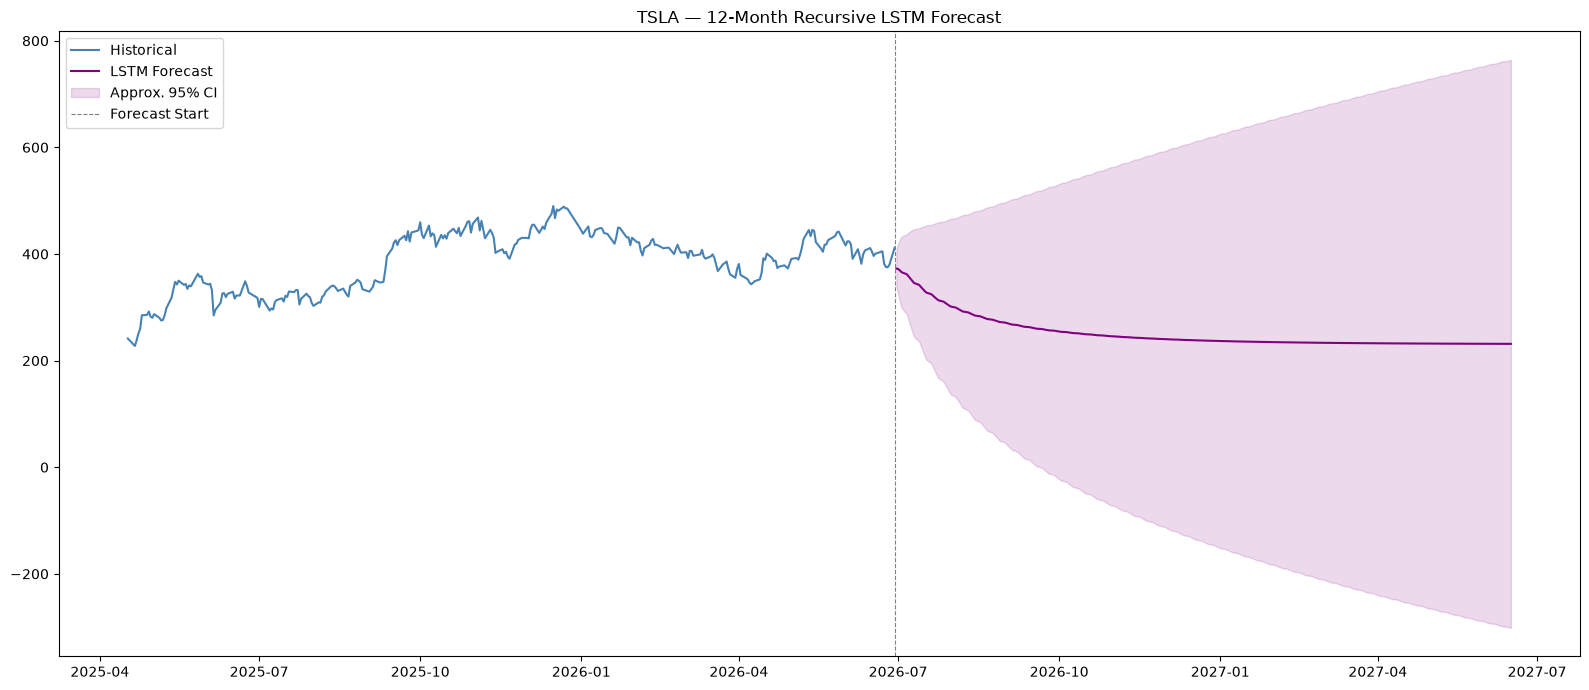

In [7]:
plt.figure(figsize=(16,7))
plt.plot(tsla.index[-300:], tsla["Adj Close"][-300:], label="Historical", color="steelblue")
plt.plot(future_dates, future_forecast, label="LSTM Forecast", color="purple")
plt.fill_between(future_dates, lower_bound, upper_bound, color="purple", alpha=0.15, label="Approx. 95% CI")
plt.axvline(tsla.index[-1], color="gray", linestyle="--", linewidth=0.8, label="Forecast Start")
plt.legend()
plt.title("TSLA — 12-Month Recursive LSTM Forecast")
plt.tight_layout()
plt.show()